## 1. Import Libraries

In [23]:
import pandas as pd
import matplotlib.pyplot as plt




## 2. Load Data



In [24]:
FILE = r'C:\Users\Ibrahim\OneDrive\Documents\Final Project\Egypt_Tourism_Full_v4_dims.xlsx'

sheets = pd.read_excel(FILE, sheet_name=None)

main = sheets['Main_Data'].copy()
dim_country = sheets['Dim_Country'].copy()
dim_dest = sheets['Dim_Destination'].copy()
dim_date = sheets['Dim_Date'].copy()

print(f"Main_Data: {main.shape[0]} rows, {main.shape[1]} columns")
main.head()


Main_Data: 17978 rows, 27 columns


,Fact_Key,Date_Key,Dest_Key,Country_Key,Year,Month,Tourist_Arrivals,Tourism_Revenue_USD,Avg_Spend_Per_Tourist_USD,Hotel_Occupancy_Rate_pct,...,Active_Nile_Cruise_Boats,Nile_Cruise_Hub,Entry_Point,Transport_Source,Avg_Daily_Spend_USD,ADR_USD,RevPAR_USD,ADR_EGP,USD_EGP_Rate,Avg_Flight_Cost_USD
0,200501_AE_CAI_AIR,200501,CAI,AE,2005,1,15654,7708499,492.43,71.8,...,0,0,Airport_Cairo_Intl,CAPMAS_UNWTO_Calibrated,75.16,83.99,60.30,482,5.75,213
1,200501_AE_CAI_LAND,200501,CAI,AE,2005,1,3786,943016,249.08,72.7,...,0,0,Border_Sinai_Salloum,CAPMAS_UNWTO_Calibrated,41.09,82.09,59.68,472,5.75,0
2,200501_AE_CAI_SEA,200501,CAI,AE,2005,1,137,9846,71.87,71.2,...,0,0,Port_Alexandria,CAPMAS_UNWTO_Calibrated,37.04,79.16,56.36,455,5.75,185
3,200501_FR_CAI_AIR,200501,CAI,FR,2005,1,46826,19721238,421.16,71.0,...,0,0,Airport_Cairo_Intl,CAPMAS_UNWTO_Calibrated,64.55,83.46,59.26,479,5.75,270
4,200501_FR_CAI_LAND,200501,CAI,FR,2005,1,6071,1683488,277.30,73.9,...,0,0,Border_Sinai_Salloum,CAPMAS_UNWTO_Calibrated,40.30,83.34,61.59,479,5.75,0


In [39]:
df = main.merge(dim_country[['Country_Key', 'Country_Name']], on='Country_Key', how='left')
df = df.merge(dim_dest[['Dest_Key', 'Destination_Name']], on='Dest_Key', how='left')
df = df.merge(dim_date[['Date_Key','Quarter']], on='Date_Key', how='left')
df[['Country_Name', 'Destination_Name', 'Year', 'Tourist_Arrivals', 'Tourism_Revenue_USD']].head()


,Country_Name,Destination_Name,Year,Tourist_Arrivals,Tourism_Revenue_USD
0,United Arab Emirates,Cairo,2005,15654,7708499
1,United Arab Emirates,Cairo,2005,3786,943016
2,United Arab Emirates,Cairo,2005,137,9846
3,France,Cairo,2005,46826,19721238
4,France,Cairo,2005,6071,1683488


## 3. Quick Look at the Data



In [26]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print(f"Year range: {df['Year'].min()} - {df['Year'].max()}")


Missing values: 0
Duplicate rows: 0
Year range: 2005 - 2024


In [27]:
key_cols = ['Tourist_Arrivals', 'Tourism_Revenue_USD', 'Avg_Spend_Per_Tourist_USD', 'Hotel_Occupancy_Rate_pct']
df[key_cols].describe().round(2)


,Tourist_Arrivals,Tourism_Revenue_USD,Avg_Spend_Per_Tourist_USD,Hotel_Occupancy_Rate_pct
count,17978.00,1.797800e+04,17978.00,17978.00
mean,10937.49,8.542338e+06,422.06,54.68
std,20071.01,2.305973e+07,362.36,18.02
min,10.00,8.240000e+02,29.53,5.00
25%,598.25,8.374425e+04,119.57,40.90
50%,4074.00,1.045401e+06,325.78,56.40
75%,11659.25,6.260692e+06,617.37,68.00
max,277379.00,4.532484e+08,2422.20,98.00


## 4. Tourism Trend Over the Years (2005–2024)



In [40]:
yearly = df.groupby('Year').agg(
    Arrivals=('Tourist_Arrivals', 'sum'),
    Revenue=('Tourism_Revenue_USD', 'sum')
).reset_index()

yearly


,Year,Arrivals,Revenue
0,2005,7936205,3778792173
1,2006,8745280,4525498985
2,2007,10216653,5532837272
3,2008,11833285,6775126215
4,2009,11458068,7056318753
5,2010,13512226,8766077020
6,2011,9401972,6929860480
7,2012,10698799,7938556257
8,2013,8760928,6595023905
9,2014,9206353,6955275981


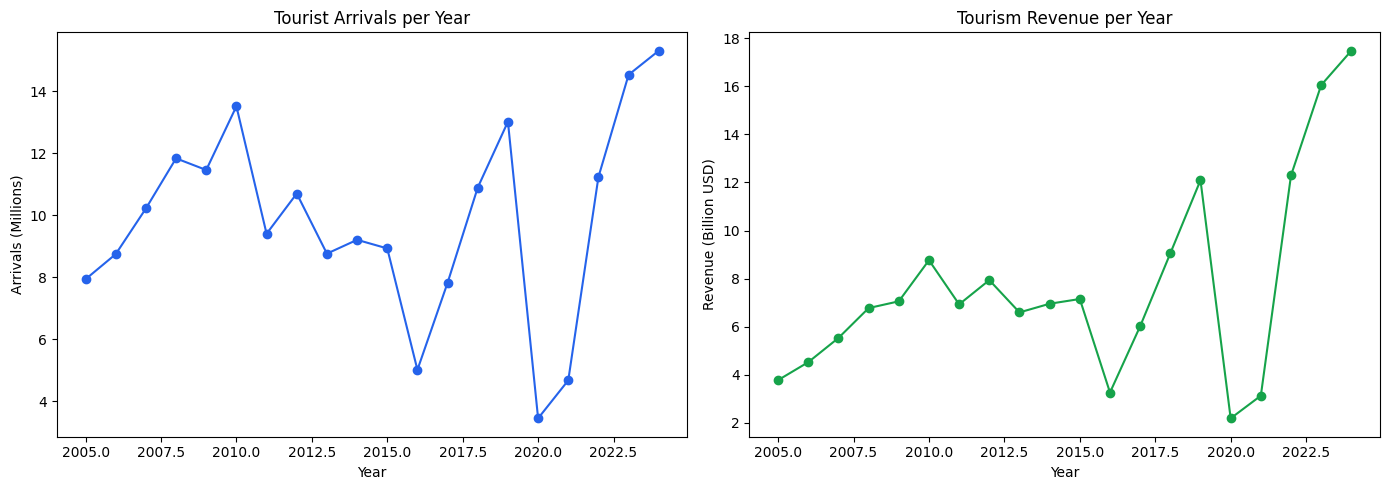

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(yearly['Year'], yearly['Arrivals'] / 1e6, marker='o', color='#2563EB')
axes[0].set_title('Tourist Arrivals per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Arrivals (Millions)')

axes[1].plot(yearly['Year'], yearly['Revenue'] / 1e9, marker='o', color='#16A34A')
axes[1].set_title('Tourism Revenue per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Revenue (Billion USD)')

plt.tight_layout()
plt.show()


## 5. Top 10 Source Countries (by Revenue)

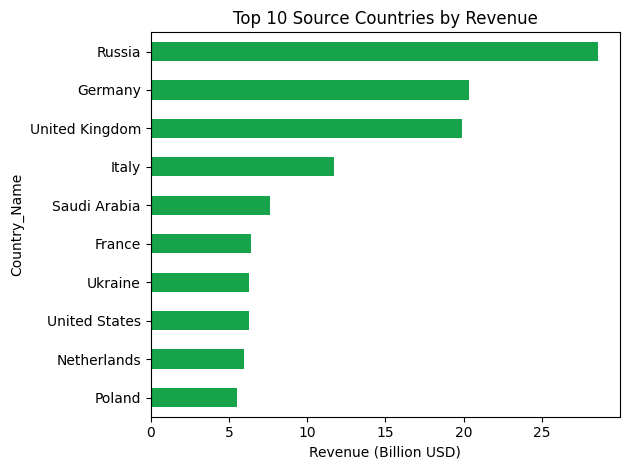

In [42]:
top_countries = (
    df.groupby('Country_Name')['Tourism_Revenue_USD']
    .sum()
    .sort_values(ascending=False)
    .head(10) / 1e9
)

fig, ax = plt.subplots()
top_countries.sort_values().plot(kind='barh', ax=ax, color='#16A34A')
ax.set_xlabel('Revenue (Billion USD)')
ax.set_title('Top 10 Source Countries by Revenue')
plt.tight_layout()
plt.show()


## 6. Destination Performance



In [43]:
dest_summary = df.groupby('Destination_Name').agg(
    Arrivals=('Tourist_Arrivals', 'sum'),
    Revenue=('Tourism_Revenue_USD', 'sum')
).reset_index().sort_values('Revenue', ascending=False)

dest_summary


,Destination_Name,Arrivals,Revenue
3,Hurghada,99545134,81322149995
6,Sharm El Sheikh,39491985,37083352900
1,Cairo,43080521,27559953517
5,Marsa Alam,5300268,3993759812
2,Dahab,3648730,1814085498
4,Luxor,2875997,1243609164
0,Borg El Arab (Alexandria),2691556,557242666


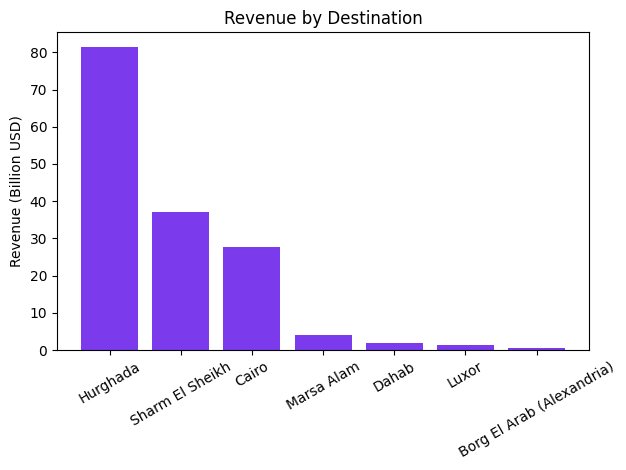

In [44]:
fig, ax = plt.subplots()
ax.bar(dest_summary['Destination_Name'], dest_summary['Revenue'] / 1e9, color='#7C3AED')
ax.set_ylabel('Revenue (Billion USD)')
ax.set_title('Revenue by Destination')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 7. Effect of Season on Arrivals



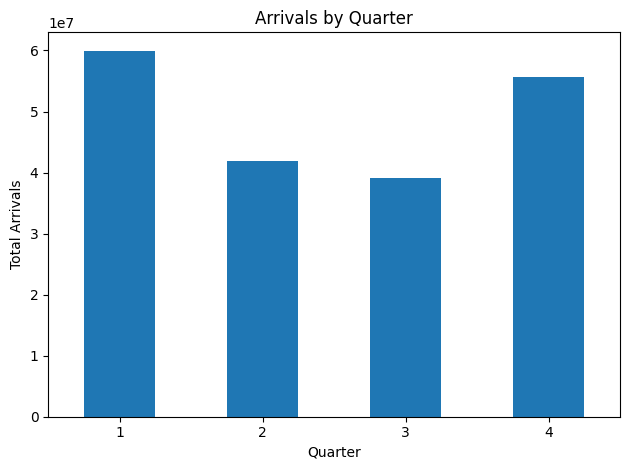

In [47]:
quarter_order = [1, 2, 3, 4]

quarter_summary = (
    df.groupby('Quarter')['Tourist_Arrivals']
      .sum()
      .reindex(quarter_order)
)

fig, ax = plt.subplots()
quarter_summary.plot(kind='bar', ax=ax)

ax.set_ylabel('Total Arrivals')
ax.set_title('Arrivals by Quarter')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Transport Mode 

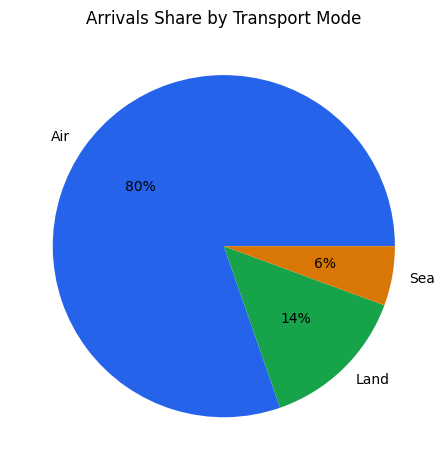

In [48]:
trans_share = df.groupby('Transport_Mode')['Tourist_Arrivals'].sum()

fig, ax = plt.subplots()
ax.pie(trans_share, labels=trans_share.index, autopct='%1.0f%%',
       colors=['#2563EB', '#16A34A', '#D97706'])
ax.set_title('Arrivals Share by Transport Mode')
plt.tight_layout()
plt.show()


## 9. KPI

In [49]:
total_arrivals = df['Tourist_Arrivals'].sum()
total_revenue = df['Tourism_Revenue_USD'].sum()
avg_spend = df['Avg_Spend_Per_Tourist_USD'].mean()
avg_occupancy = df['Hotel_Occupancy_Rate_pct'].mean()

print(f"Total Arrivals (2005-2024):     {total_arrivals/1e6:.1f} Million")
print(f"Total Revenue (2005-2024):      ${total_revenue/1e9:.1f} Billion")
print(f"Average Spend per Tourist:      ${avg_spend:,.0f}")
print(f"Average Hotel Occupancy Rate:   {avg_occupancy:.1f}%")


Total Arrivals (2005-2024):     196.6 Million
Total Revenue (2005-2024):      $153.6 Billion
Average Spend per Tourist:      $422
Average Hotel Occupancy Rate:   54.7%
